# Kombinasi Game Theory & VQE

Notebook ini menggabungkan analisis Teori Permainan Kuantum (Quantum Game Theory) untuk ekstraksi parameter pasar dengan algoritma Variational Quantum Eigensolver (VQE) untuk optimasi portofolio/strategi.

## Alur Kerja:
1. **Ekstraksi Data**: Mengambil data historis Emas (GC=F) dan Perak (SI=F).
2. **Analisis Game Theory**: Menghitung Payoff Matrix dan Quantum Mutual Information (QMI).
3. **Konstruksi Hamiltonian**: Membangun Hamiltonian Ising berdasarkan parameter bias dan interaksi dari QMI.
4. **VQE Execution**: Mencari Ground State (Quantum Nash Equilibrium) menggunakan Hardware-Efficient Ansatz.

In [2]:
# 1. Setup & Imports
import pennylane as qml
from pennylane import numpy as np
import yfinance as yf
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.linalg as la

# Device setup
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.0


In [3]:
# 2. Data Extraction & Game Theory Analysis

def get_market_data(tickers, period="2y"):
    print(f"Downloading data for: {tickers}")
    data = yf.download(tickers, period=period)['Close']
    returns = data.pct_change().dropna()
    return returns

def analyze_quantum_game(returns, leader_col, follower_col):
    # State 0 (Up) if return >= 0, State 1 (Down) if return < 0
    L_state = (returns[leader_col] < 0).astype(int)
    F_state = (returns[follower_col] < 0).astype(int)

    n_ij = np.zeros((2, 2))
    sum_L = np.zeros((2, 2))
    sum_F = np.zeros((2, 2))

    for i in range(len(returns)):
        l = L_state.iloc[i]
        f = F_state.iloc[i]
        n_ij[l, f] += 1
        sum_L[l, f] += returns[leader_col].iloc[i]
        sum_F[l, f] += returns[follower_col].iloc[i]

    n_total = n_ij.sum()
    
    # Payoff Matrices (Lead & Follow)
    # Add small epsilon to avoid division by zero
    payoff_L = sum_L / (n_ij + 1)
    payoff_F = sum_F / (n_ij + 1)

    prob_matrix = n_ij / n_total
    
    return payoff_L, payoff_F, prob_matrix

# Execute Data Extraction
tickers = ['GC=F', 'SI=F']
try:
    data_returns = get_market_data(tickers)
    # Check if columns exist (yfinance sometimes returns MultiIndex)
    if isinstance(data_returns.columns, pd.MultiIndex):
        data_returns.columns = data_returns.columns.get_level_values(0)
        
    pL, pF, probs = analyze_quantum_game(data_returns, 'GC=F', 'SI=F')
    
    print("Payoff Matrix L (Gold):\n", pL)
    print("Payoff Matrix F (Silver):\n", pF)
    print("Probability Matrix:\n", probs)
except Exception as e:
    print(f"Error fetching data: {e}\nUsing dummy data for demonstration.")
    pL = np.array([[0.01, 0.005], [-0.005, -0.01]])
    pF = np.array([[0.02, -0.01], [0.01, -0.02]])
    probs = np.array([[0.6, 0.1], [0.1, 0.2]])

[*********************100%***********************]  2 of 2 completed


Payoff Matrix L (Gold):
 [[ 0.01044808  0.00442225]
 [-0.00441347 -0.01066548]]
Payoff Matrix F (Silver):
 [[ 0.02043093 -0.00925464]
 [ 0.0071496  -0.02165175]]
Probability Matrix:
 [[0.46626984 0.12896825]
 [0.11111111 0.29365079]]


In [4]:
# 3. Quantum Mutual Information & Hamiltonian Construction

def calculate_qmi(probs):
    # Construct Density Matrices
    # Global (Pure state approximation from probs)
    rho_LF = probs / np.sum(probs)
    
    # Reduced Density Matrices (trace out other system)
    # rho_L = Tr_F(rho_LF)
    rho_L = np.diag([probs[0,0] + probs[0,1], probs[1,0] + probs[1,1]])
    # rho_F = Tr_L(rho_LF)
    rho_F = np.diag([probs[0,0] + probs[1,0], probs[0,1] + probs[1,1]])

    def vn_entropy(rho):
        ev = la.eigvalsh(rho)
        # Remove near-zero eigenvalues for log stability
        ev = ev[ev > 1e-12]
        return -np.sum(ev * np.log2(ev))

    # I(L:F) = S(L) + S(F) - S(LF)
    return vn_entropy(rho_L) + vn_entropy(rho_F) - vn_entropy(rho_LF)

qmi = calculate_qmi(probs)
print(f"Quantum Mutual Information: {qmi:.4f}")

# Define Hamiltonian Parameters
# H = -h_L * Z0 - h_F * Z1 - J_LF * (Z0 @ Z1)
# Bias h ~ Expectation difference
h_L = (pL[0,0] + pL[0,1]) - (pL[1,0] + pL[1,1])
h_F = (pF[0,0] + pF[1,0]) - (pF[0,1] + pF[1,1])
J_LF = qmi * 0.5  # Scale interaction by QMI

print(f"Hamiltonian Parameters: h_L={h_L:.4f}, h_F={h_F:.4f}, J_LF={J_LF:.4f}")

# Construct PennyLane Hamiltonian
obs = [
    qml.PauliZ(0), 
    qml.PauliZ(1), 
    qml.PauliZ(0) @ qml.PauliZ(1)
]
coeffs = [-h_L, -h_F, -J_LF]
H = qml.Hamiltonian(coeffs, obs)
print("\nHamiltonian:\n", H)

Quantum Mutual Information: 0.9724
Hamiltonian Parameters: h_L=0.0299, h_F=0.0585, J_LF=0.4862

Hamiltonian:
 -0.02994927320658048 * Z(0) + -0.058486922207497384 * Z(1) + -0.4861960199031934 * (Z(0) @ Z(1))


In [5]:
# 4. Hardware-Efficient Ansatz

def hardware_efficient_ansatz(weights, wires, depth):
    """
    Hardware Efficient Ansatz using Euler Rotations (RZ-RX-RZ) and CNOTs.
    weights shape: (depth + 1, n_qubits, 3)
    """
    # Initial Rotations (Layer 0)
    for i in wires:
        qml.RZ(weights[0, i, 0], wires=i)
        qml.RX(weights[0, i, 1], wires=i)
        qml.RZ(weights[0, i, 2], wires=i)
        
    for d in range(depth):
        # Entanglement (Linear topology for 2 qubits)
        qml.CNOT(wires=[wires[0], wires[1]])
        
        # Layer Rotations
        for i in wires:
            qml.RZ(weights[d+1, i, 0], wires=i)
            qml.RX(weights[d+1, i, 1], wires=i)
            qml.RZ(weights[d+1, i, 2], wires=i)

depth = 2
param_shape = (depth + 1, n_qubits, 3)
num_params = np.prod(param_shape)
print(f"Ansatz Depth: {depth}")
print(f"Total Parameters: {num_params}")

Ansatz Depth: 2
Total Parameters: 18


Starting Optimization...
Iter   0: Cost = 0.389807
Iter  10: Cost = -0.369710
Iter  20: Cost = -0.488143
Iter  30: Cost = -0.557866
Iter  40: Cost = -0.566261
Iter  50: Cost = -0.572918
Iter  60: Cost = -0.573150
Iter  70: Cost = -0.574543
Iter  80: Cost = -0.574418
Iter  90: Cost = -0.574595
Final Cost: -0.574610


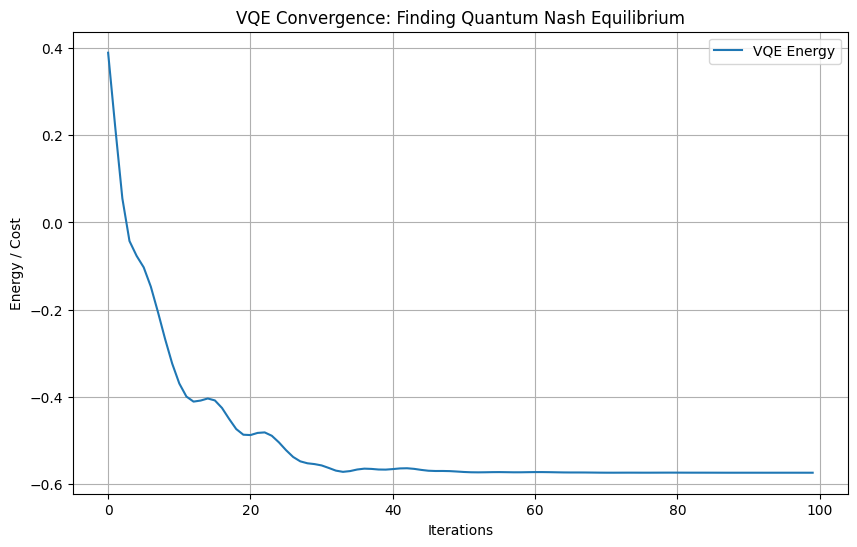

In [6]:
# 5. VQE Execution

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def cost_fn(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.expval(H)

# Classical Optimizer
opt = qml.AdamOptimizer(stepsize=0.1)

# Initialize weights uniformly
np.random.seed(42)
weights = np.random.random(param_shape, requires_grad=True) * 2 * np.pi

max_iter = 100
costs = []

print("Starting Optimization...")
for i in range(max_iter):
    weights, cost = opt.step_and_cost(cost_fn, weights)
    costs.append(cost)
    
    if i % 10 == 0:
        print(f"Iter {i:3d}: Cost = {cost:.6f}")

print(f"Final Cost: {costs[-1]:.6f}")

# Visualizing Convergence
plt.figure(figsize=(10, 6))
plt.plot(costs, label='VQE Energy')
plt.xlabel('Iterations')
plt.ylabel('Energy / Cost')
plt.title('VQE Convergence: Finding Quantum Nash Equilibrium')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# 6. Analysis and Verification

# Extract Optimal State
@qml.qnode(dev)
def get_probs(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.probs(wires=[0, 1])

probs_vqe = get_probs(weights)
states = ["|00> (Both Up)", "|01> (Lead Up, Fol Down)", "|10> (Lead Down, Fol Up)", "|11> (Both Down)"]

print("\n--- Optimal Quantum State ---")
for s, p in zip(states, probs_vqe):
    print(f"{s}: {p:.4f}")

dominant_idx = np.argmax(probs_vqe)
print(f"\nDominant Strategy (Nash Equilibrium): {states[dominant_idx]}")

# Verification with Exact Diagonalization
H_matrix = qml.matrix(H)
# H is wrapped, getting simple matrix
if hasattr(H_matrix, "todense"): # handle sparse if needed
    H_matrix = H_matrix.todense()

eigvals, eigvecs = la.eigh(H_matrix)
exact_min_energy = eigvals[0]

print(f"\n--- Verification ---")
print(f"VQE Minimum Energy: {costs[-1]:.6f}")
print(f"Exact Minimum Energy: {exact_min_energy:.6f}")
diff = abs(costs[-1] - exact_min_energy)
print(f"Difference: {diff:.6f}")

if diff < 1e-2:
    print("✅ SUCCESS: VQE successfully found the ground state (Nash Equilibrium)!")
else:
    print("⚠️ WARNING: Convergence might not be optimal. Try increasing depth or iterations.")


--- Optimal Quantum State ---
|00> (Both Up): 0.9999
|01> (Lead Up, Fol Down): 0.0000
|10> (Lead Down, Fol Up): 0.0000
|11> (Both Down): 0.0001

Dominant Strategy (Nash Equilibrium): |00> (Both Up)

--- Verification ---
VQE Minimum Energy: -0.574610
Exact Minimum Energy: -0.574632
Difference: 0.000023
✅ SUCCESS: VQE successfully found the ground state (Nash Equilibrium)!
